In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

In [2]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'
#DATA_DIR    = '/Users/zoecas/Documents/data/'

DATA_SUBDIR = 'diags_2024/'
filename = 'swot_segments2D_250km_demean_swh5.nc'

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── File parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 250.0
BOX_DEG = 1.0
#filename_pattern = f'{int(SEGMENT_LENGTH_KM)}km_notide_demean_sw6.nc'
#filename_pattern ="1000km_notide_demean_swh6.nc"


# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)

In [3]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all      = ds_segments['psd'].values
    psd2d_all    = ds_segments['psd2D'].values
    wavenumber   = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd, rows_psd2d = [], [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_psd2d.append(np.nanmean(psd2d_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    psd2d_stack  = np.stack(rows_psd2d, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            mean_psd2D=(['box', 'wavenumber'], psd2d_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker


def plot_box(var : np.array, lon : np.array, lat : np.array,
             projection : ccrs = ccrs.Robinson(), cmap : str="viridis", 
             min_size : int=20, max_size : int=300, figsize : tuple=(14, 7),
             title : str = "Number of observations per box", label : str = "Number of observations",
             norm : norm = None, vmin : float = None, vmax : float = None, box_deg : float = BOX_DEG
            ):

    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

    gl.xlabel_style = {"size": 10,"color": "black",}

    gl.ylabel_style = {"size": 10,"color": "black",}
    
    if norm is not None:
        sc = ax.scatter(lon,lat,s=45,c=var,
                    cmap=cmap,edgecolors=None,linewidths=0.25,
                    transform=ccrs.PlateCarree(),norm = norm)
    else:
        if vmin is None:
            vmin,vmax=np.nanmin(var),np.nanmax(var)
        if box_deg <=0.0 :
            sc = ax.pcolormesh(var,lon,lat,
                              cmap=cmap,vmin = vmin, vmax = vmax,
                            transform=ccrs.PlateCarree())
        else:
            sc = ax.scatter(lon,lat,s=45,c=var,
                        cmap=cmap,edgecolors=None,linewidths=0.25,
                        transform=ccrs.PlateCarree(),vmin = vmin, vmax = vmax)

    cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
    cb.set_label(label)
    ax.set_title(title)
    
    return fig, ax

In [4]:
ds = xr.open_dataset(DATA_DIR+DATA_SUBDIR+filename)
ds_boxes = build_box_dataset(ds,box_deg=BOX_DEG)
ds

<xarray.Dataset> Size: 2GB
Dimensions:         (segment: 1299491, wavenumber: 63)
Coordinates:
  * segment         (segment) int64 10MB 0 1 2 3 ... 1299488 1299489 1299490
  * wavenumber      (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    psd             (segment, wavenumber) float64 655MB 0.002382 ... 1.181e-05
    psd2D           (segment, wavenumber) float64 655MB 0.02861 ... 3.92e-06
    lat_mean        (segment) float64 10MB 27.81 23.38 22.28 ... 58.05 59.08
    lat_min         (segment) float64 10MB ...
    lat_max         (segment) float64 10MB ...
    lon_mean        (segment) float64 10MB 248.1 248.9 249.1 ... 305.5 306.3
    n_pixels_used   (segment) int64 10MB ...
    valid_fraction  (segment) float64 10MB ...
    swath           (segment) <U5 26MB ...
    granule         (segment) <U69 359MB ...
    year            (segment) int64 10MB ...
    month           (segment) int64 10MB ...

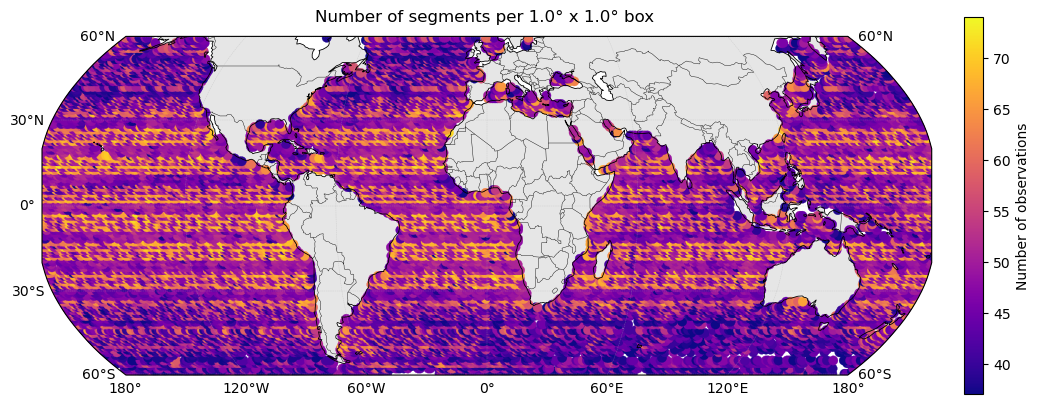

In [5]:
fig, ax = plot_box(ds_boxes["n_segments"].values,
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

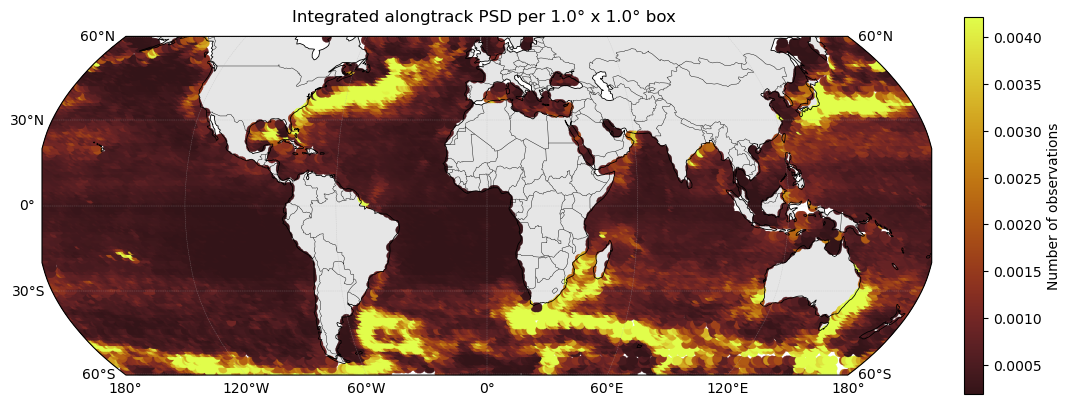

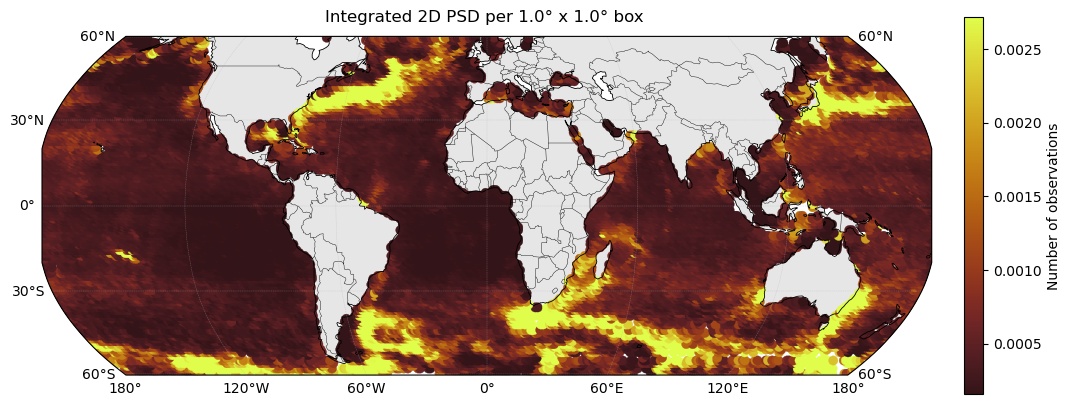

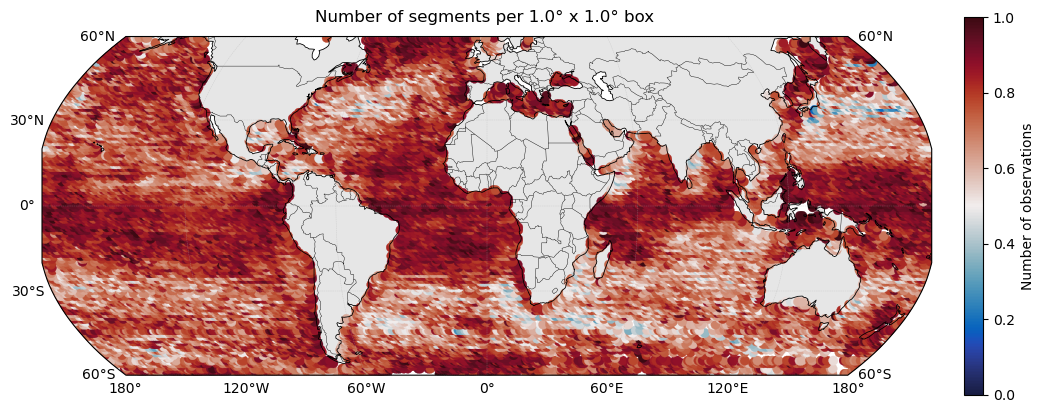

In [6]:
import cmocean

K_MIN, K_MAX = 1/500, 1/6

energy = ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

energy = ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated 2D PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

ratio = ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')/ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(ratio,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.balance, vmin = 0, vmax = 1,
                   title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

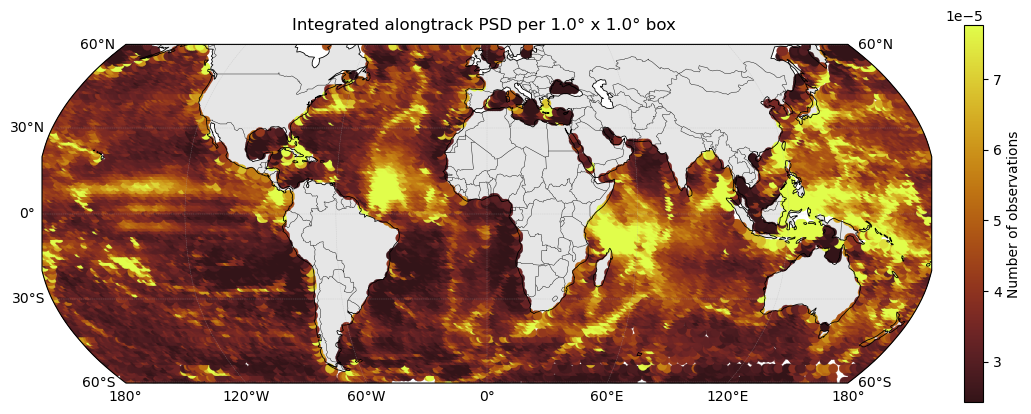

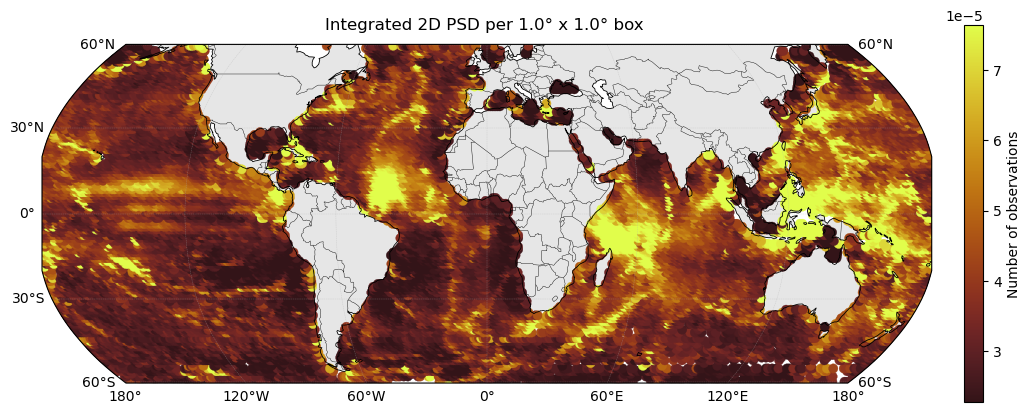

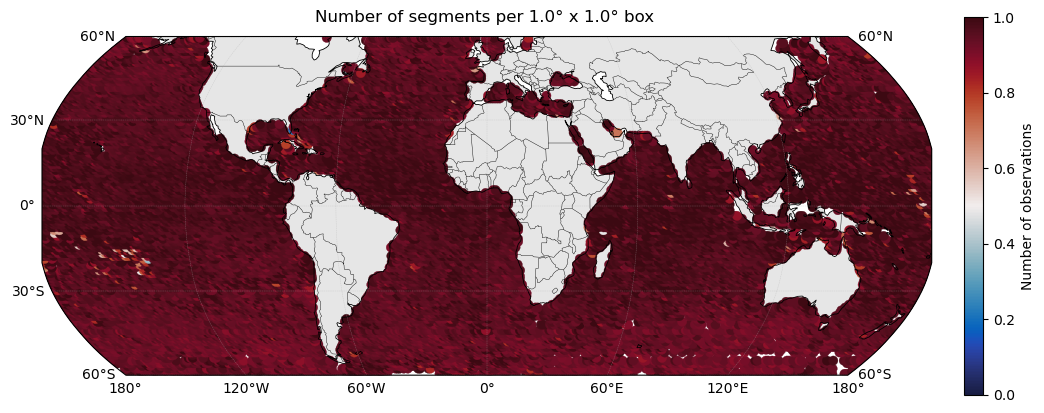

In [7]:
K_MIN, K_MAX = 1/50, 1/6

energy = ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

energy = ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated 2D PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

ratio = (ds_boxes["mean_psd2D"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
        )/ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(ratio,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.balance, vmin = 0, vmax = 1,
                   title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

In [8]:
latmin, latmax = -5, 30
lonmin, lonmax = 280, 330
ds_sub = ds.where((ds.lon_mean<=lonmax) & (ds.lon_mean>=lonmin) &
                  (ds.lat_mean<=latmax) & (ds.lat_mean>=latmin), drop=True)

In [10]:
ds_boxes_01 = build_box_dataset(ds.where(ds.month==1,drop=True),box_deg=BOX_DEG)
ds_boxes_08 = build_box_dataset(ds.where(ds.month==8,drop=True),box_deg=BOX_DEG)

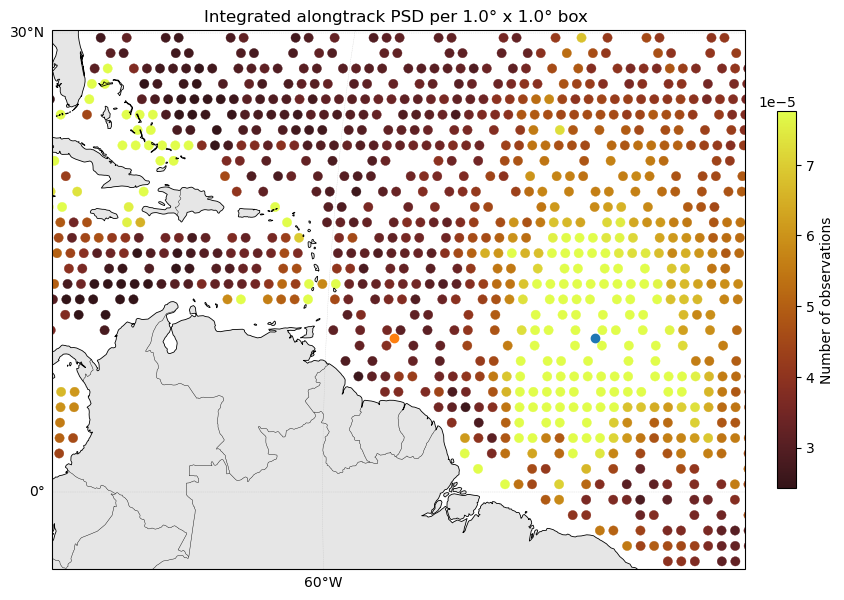

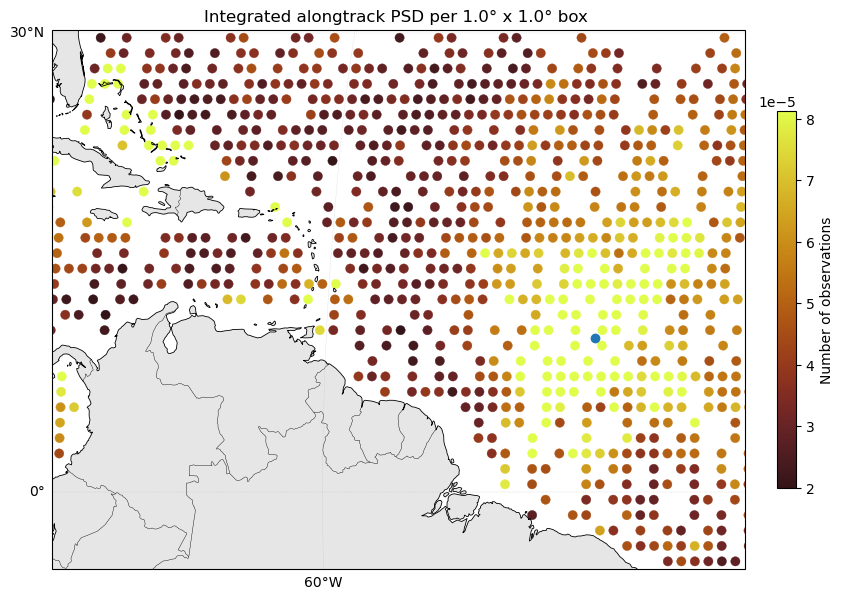

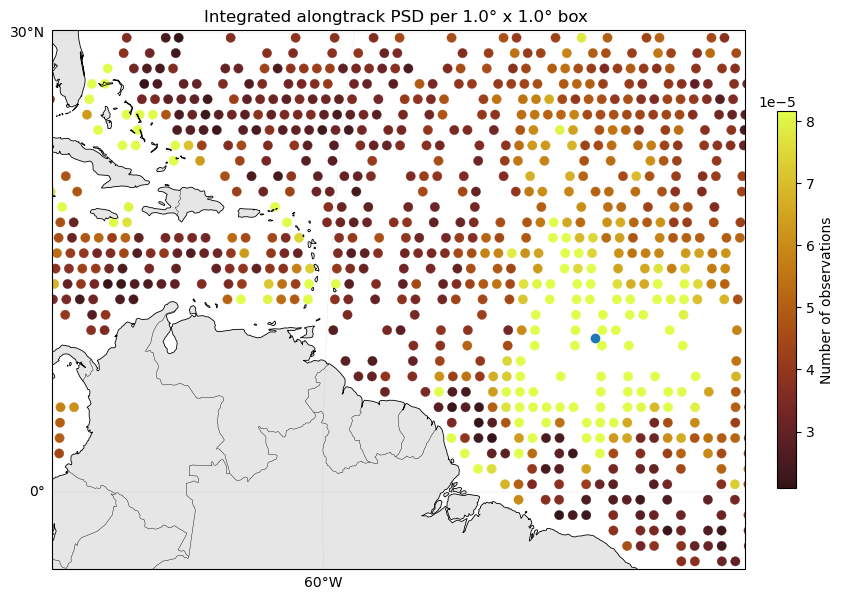

In [11]:
K_MIN, K_MAX = 1/50, 1/6

energy = ds_boxes["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes["lon_center"],
                   ds_boxes["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([280,330,-5,30], crs=ccrs.PlateCarree())
ax.scatter(320,10, transform=ccrs.PlateCarree())
ax.scatter(305,10, transform=ccrs.PlateCarree())
plt.show()


energy = ds_boxes_01["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes_01["lon_center"],
                   ds_boxes_01["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([280,330,-5,30], crs=ccrs.PlateCarree())
ax.scatter(320,10, transform=ccrs.PlateCarree())
plt.show()

energy = ds_boxes_08["mean_psd"].sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
fig, ax = plot_box(energy,
                   ds_boxes_08["lon_center"],
                   ds_boxes_08["lat_center"],
                   cmap=cmocean.cm.solar, vmin = np.nanpercentile(energy,5), vmax = np.nanpercentile(energy,95),
                   title=f"Integrated alongtrack PSD per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([280,330,-5,30], crs=ccrs.PlateCarree())
ax.scatter(320,10, transform=ccrs.PlateCarree())
plt.show()

In [12]:
dlat, dlon = 0.5, 0.5
latc, lonc, lonc2 = 10.0, 320.0, 305.0
ds_pt = ds_sub.where((ds_sub.lat_mean<=latc+dlat) & (ds_sub.lat_mean>=latc-dlat) &
                    (ds_sub.lon_mean<=lonc+dlon) & (ds_sub.lon_mean>=lonc-dlon), drop=True)

ds_pt2 = ds_sub.where((ds_sub.lat_mean<=latc+dlat) & (ds_sub.lat_mean>=latc-dlat) &
                    (ds_sub.lon_mean<=lonc2+dlon) & (ds_sub.lon_mean>=lonc2-dlon), drop=True)


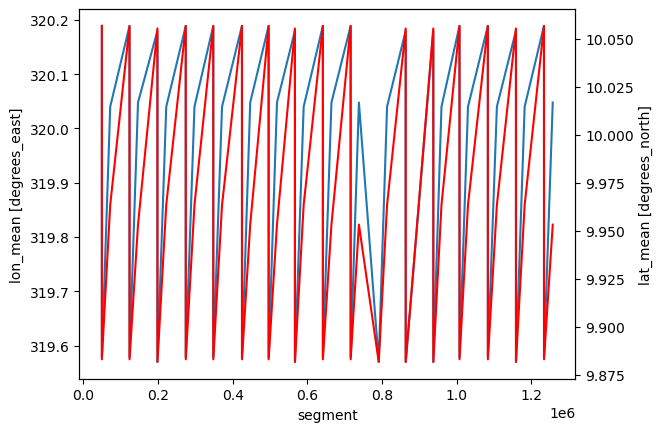

In [13]:
ds_pt.lon_mean.plot()
plt.twinx()
ds_pt.lat_mean.plot(c='r')

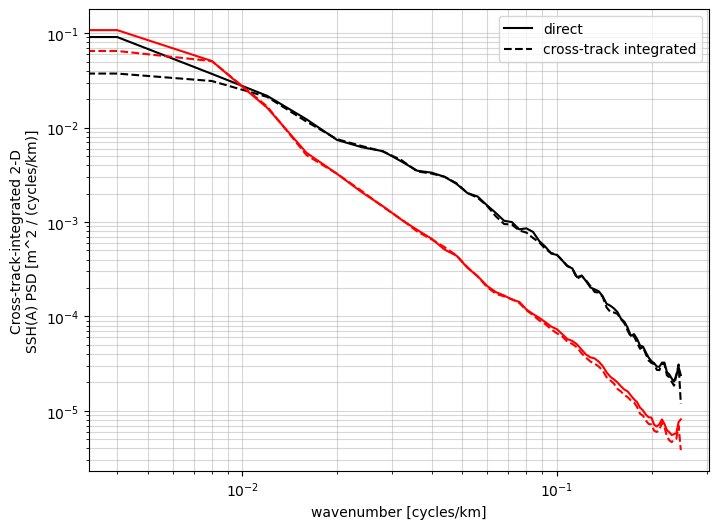

In [14]:
fig,ax = plt.subplots(figsize=(8,6))
ds_pt.psd.mean('segment').plot(ax=ax, c='k', xscale='log',yscale='log', label='direct')
ds_pt.psd2D.mean('segment').plot(ax=ax, c='k', ls='--', xscale='log',yscale='log', label='cross-track integrated')
ds_pt2.psd.mean('segment').plot(ax=ax, c='r', xscale='log',yscale='log')
ds_pt2.psd2D.mean('segment').plot(ax=ax, c='r', ls='--', xscale='log',yscale='log')
ax.grid(True,which='both',alpha=0.5);
ax.legend()

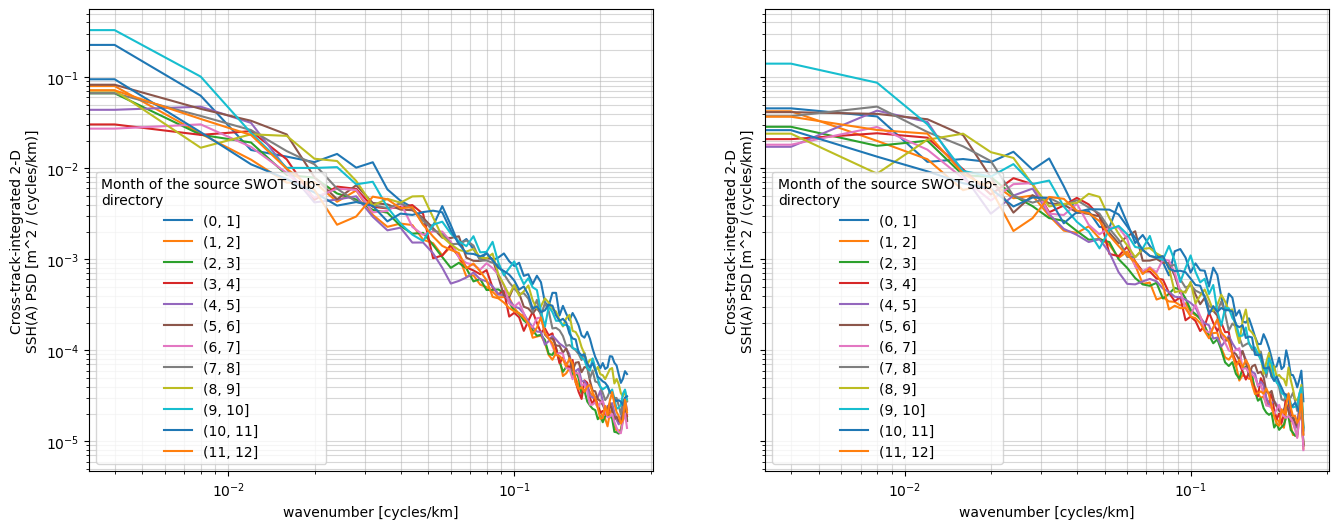

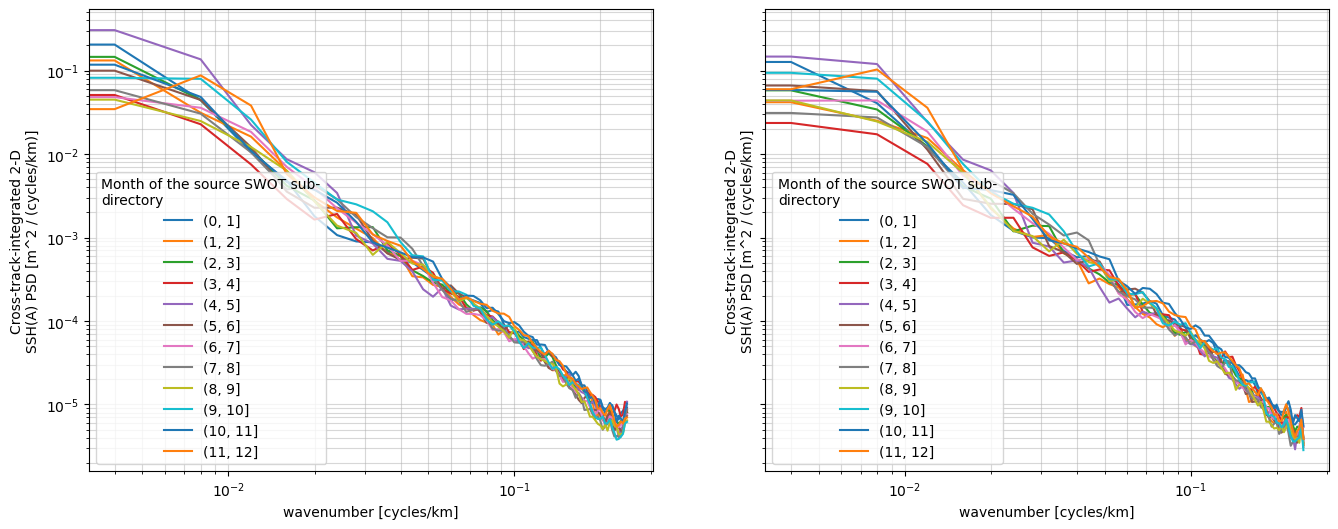

In [15]:
monthly_binned = ds_pt.groupby_bins('month',bins=np.arange(0,13)).mean()
monthly_binned2 = ds_pt2.groupby_bins('month',bins=np.arange(0,13)).mean()

fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
monthly_binned.psd.plot(ax=axs[0], hue='month_bins', xscale='log',yscale='log')
monthly_binned.psd2D.plot(ax=axs[1], hue='month_bins', xscale='log',yscale='log')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
    #ax.legend()

fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
monthly_binned2.psd.plot(ax=axs[0], hue='month_bins', xscale='log',yscale='log')
monthly_binned2.psd2D.plot(ax=axs[1], hue='month_bins', xscale='log',yscale='log')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);

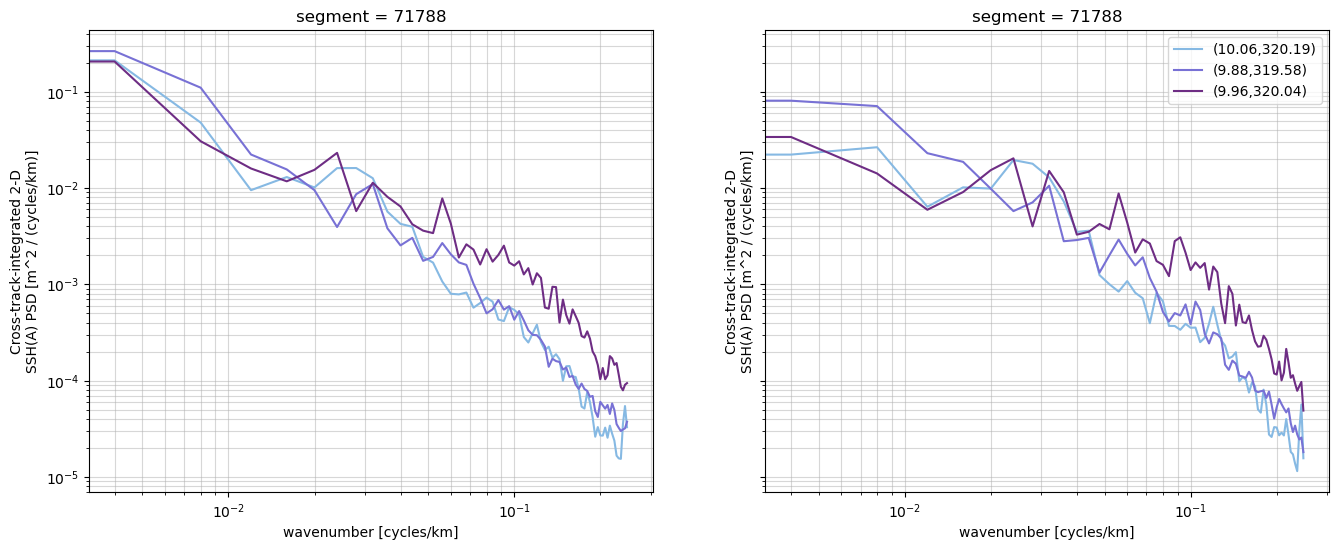

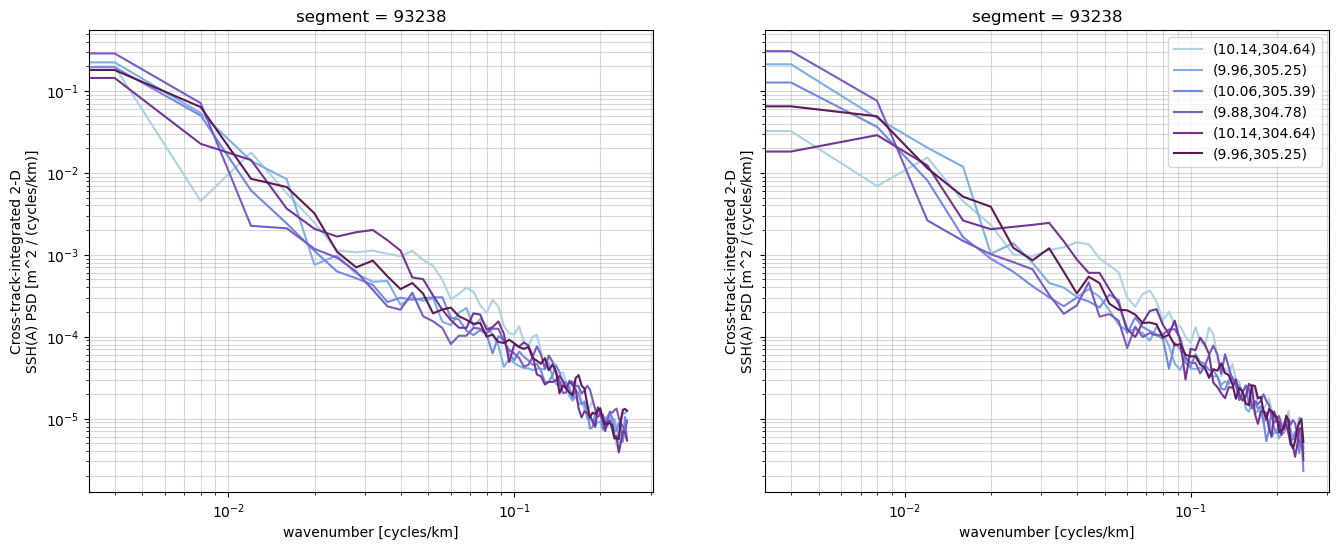

In [16]:
cmap = plt.get_cmap(cmocean.cm.dense)

norm = plt.Normalize(vmin=-1, vmax=ds_pt.where(ds_pt.month==1,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt.where(ds_pt.month==1,drop=True).segment):
    _s = ds_pt.where(ds_pt.month==1,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()


norm = plt.Normalize(vmin=-1, vmax=ds_pt2.where(ds_pt2.month==1,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt2.where(ds_pt2.month==1,drop=True).segment):
    _s = ds_pt2.where(ds_pt2.month==1,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()

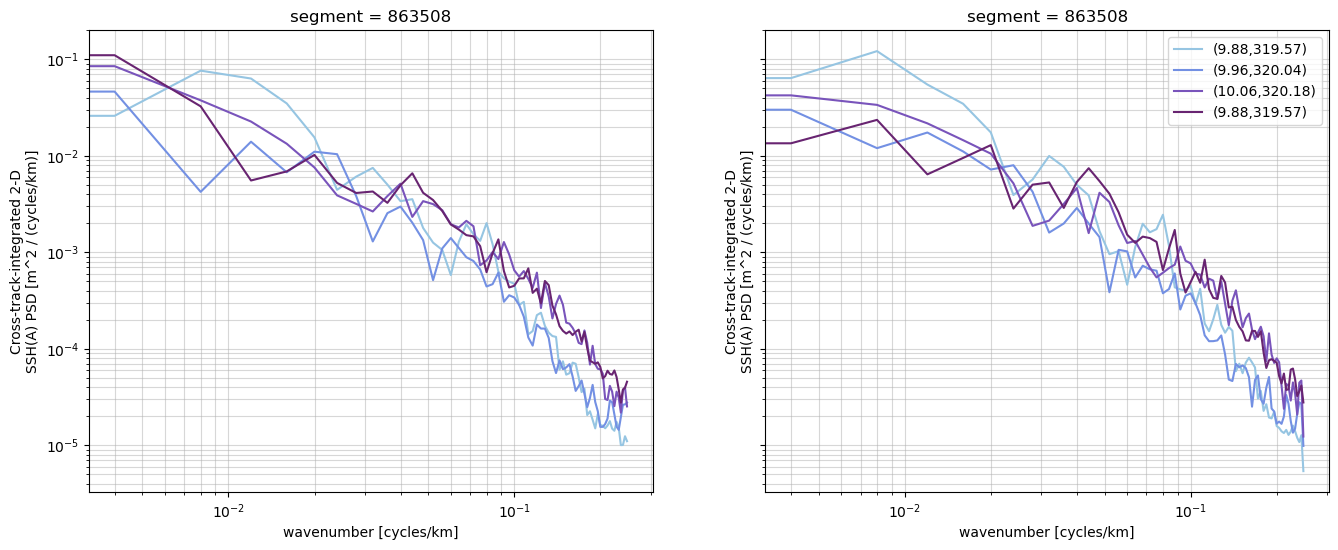

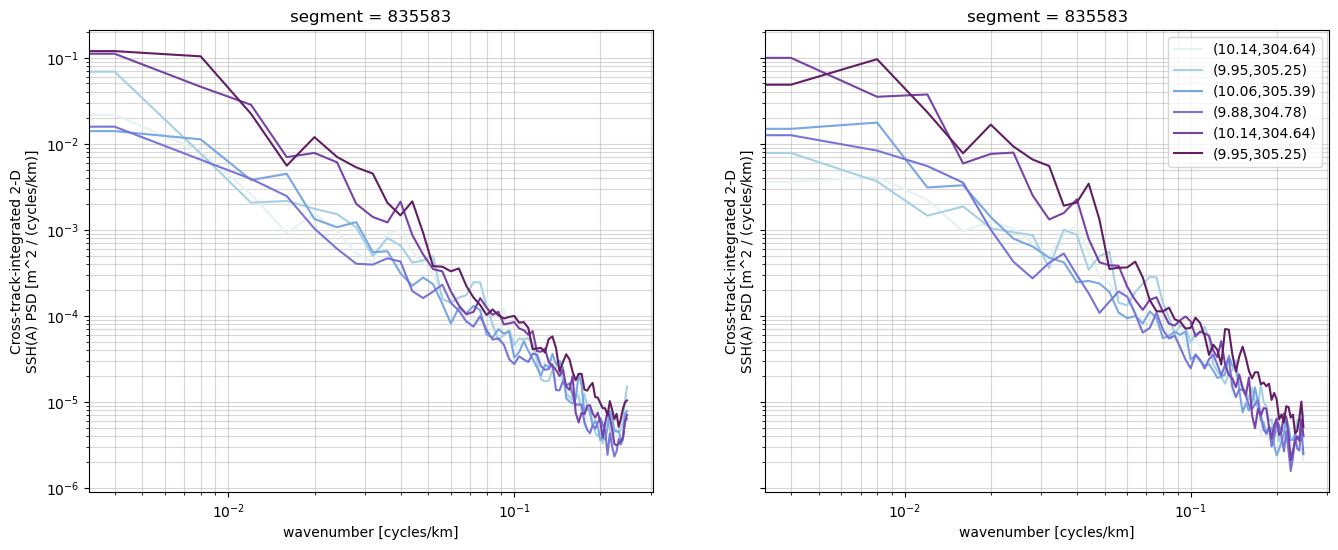

In [17]:
cmap = plt.get_cmap(cmocean.cm.dense)

norm = plt.Normalize(vmin=-1, vmax=ds_pt.where(ds_pt.month==8,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt.where(ds_pt.month==8,drop=True).segment):
    _s = ds_pt.where(ds_pt.month==8,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()


norm = plt.Normalize(vmin=0.1, vmax=ds_pt2.where(ds_pt2.month==8,drop=True).segment.size)
fig,axs = plt.subplots(1,2,figsize=(16,6), sharey=True)
for i,s in enumerate(ds_pt2.where(ds_pt2.month==8,drop=True).segment):
    _s = ds_pt2.where(ds_pt2.month==8,drop=True).sel(segment=s)
    _s.psd.plot(ax=axs[0], xscale='log',yscale='log',c=cmap(norm(i)))
    _s.psd2D.plot(ax=axs[1],c=cmap(norm(i)), xscale='log',yscale='log', label=f'({np.around(_s.lat_mean.values,decimals=2)},{np.around(_s.lon_mean.values,decimals=2)})')
for ax in axs:
    ax.grid(True,which='both',alpha=0.5);
axs[1].legend()

In [18]:
lat = np.unique(ds_boxes.lat_center)
lon = np.unique(ds_boxes.lon_center)
print(lon.size*lat.size,ds_boxes.box.size)

42480 19851
